# Chapter 028 — Prime Numbers

> **Prerequisites:** ch023 (Integers), ch022 (Natural Numbers)
> 
> **You will learn:**
> - Define primes and understand why 1 is not prime
> - Implement the Sieve of Eratosthenes
> - Understand the prime number theorem: π(n) ~ n/ln(n)
> - Connect primes to factorization and cryptography
> 
> **Environment:** Python 3.x, numpy, matplotlib

---


## 1. Concept

Prime numbers are the atoms of multiplication: every integer > 1 is either prime or a unique product of primes (Fundamental Theorem of Arithmetic).

A prime p is an integer > 1 divisible only by 1 and itself. The sequence begins: 2, 3, 5, 7, 11, 13, 17, 19, 23, ...

**Why 1 is not prime:** The Fundamental Theorem of Arithmetic guarantees *unique* factorization. If 1 were prime, 6 = 2×3 = 1×2×3 = 1×1×2×3... — infinitely many factorizations. Excluding 1 preserves uniqueness.

**Common misconception:** "2 is not prime because it's even." 2 is the *only* even prime — it is divisible only by 1 and 2.

**Practical uses:** RSA encryption (ch023 mini-project) relies on the fact that multiplying two large primes is easy, but factoring the product is computationally infeasible.

## 2. Intuition & Mental Models

**Think of primes as indivisible atoms:** Just as matter is made of atoms, integers are made of prime factors. Every integer has a unique factorization — its "prime fingerprint."

**The Sieve as elimination:** Write all integers from 2 to N. Strike out all multiples of 2 (leaving 2), then multiples of 3, then 5, etc. What remains are primes.

**Prime number theorem:** The probability that a random integer near n is prime is approximately 1/ln(n). Primes thin out as numbers grow but never stop — Euclid proved infinitely many primes in ~300 BCE with one of mathematics' most elegant arguments.

*(Recall from ch022: induction is used to prove statements about all natural numbers — the Sieve terminates at √N because any composite number ≤ N has a prime factor ≤ √N.)*

## 3. Visualization

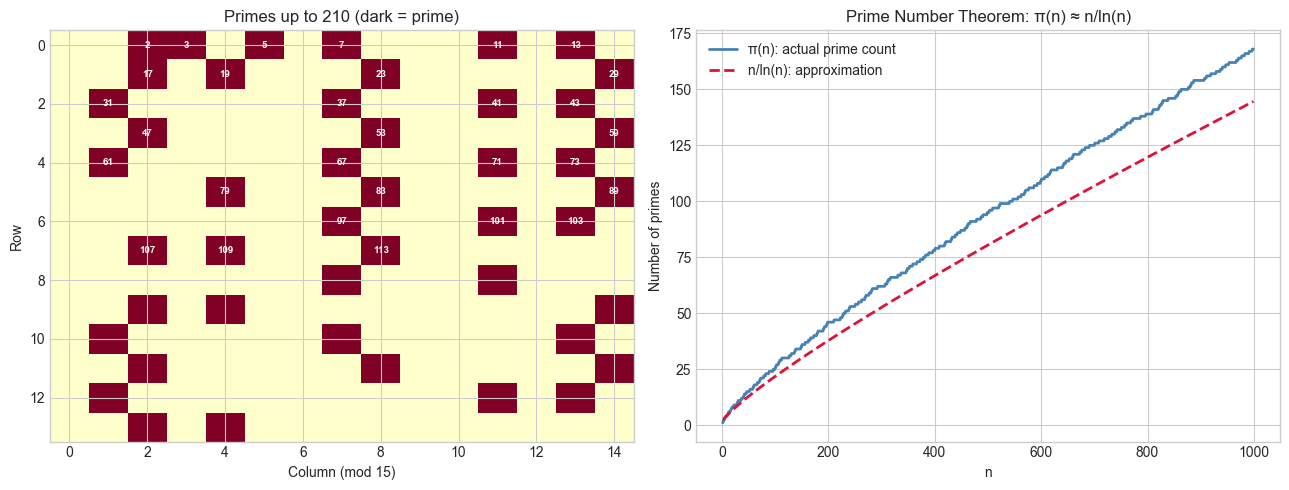

Primes up to 200: [  2   3   5   7  11  13  17  19  23  29  31  37  41  43  47  53  59  61
  67  71  73  79  83  89  97 101 103 107 109 113 127 131 137 139 149 151
 157 163 167 173 179 181 191 193 197 199]


In [1]:
# --- Visualization: Sieve of Eratosthenes and prime density ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def sieve_eratosthenes(n):
    """Return list of primes up to n using the Sieve of Eratosthenes."""
    is_prime = np.ones(n + 1, dtype=bool)
    is_prime[0] = is_prime[1] = False
    for i in range(2, int(n**0.5) + 1):
        if is_prime[i]:
            is_prime[i*i::i] = False
    return np.where(is_prime)[0]

N = 200
primes = sieve_eratosthenes(N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Prime grid visualization
ax = axes[0]
grid = np.zeros((14, 15))
for p in primes:
    if p < 14 * 15:
        grid[p // 15, p % 15] = 1
im = ax.imshow(grid, cmap='YlOrRd', aspect='auto', interpolation='nearest')
ax.set_title('Primes up to 210 (dark = prime)')
ax.set_xlabel('Column (mod 15)')
ax.set_ylabel('Row')
for p in primes[:30]:
    r, c = p // 15, p % 15
    ax.text(c, r, str(p), ha='center', va='center', fontsize=7, color='white', fontweight='bold')

# Plot 2: Prime counting function vs approximation
ax = axes[1]
ns = np.arange(2, 1000)
p_all = sieve_eratosthenes(1000)
pi_n = np.array([np.searchsorted(p_all, n, side='right') for n in ns])
ax.plot(ns, pi_n, label='π(n): actual prime count', color='steelblue', linewidth=2)
ax.plot(ns, ns / np.log(ns), '--', label='n/ln(n): approximation', color='crimson', linewidth=2)
ax.set_xlabel('n')
ax.set_ylabel('Number of primes')
ax.set_title('Prime Number Theorem: π(n) ≈ n/ln(n)')
ax.legend()

plt.tight_layout()
plt.show()
print(f"Primes up to {N}: {primes}")

## 4. Mathematical Formulation

See implementation below for numeric verification.

## 5. Python Implementation

In [2]:
# --- Implementation: Primality test and factorization ---
import math

def is_prime_trial(n):
    """
    Trial division primality test.
    Time: O(√n)

    Args:
        n: int

    Returns:
        bool
    """
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True

def prime_factorization(n):
    """
    Return prime factorization of n as dict {prime: exponent}.

    Args:
        n: int > 1

    Returns:
        dict: {p: e} meaning n = product of p^e
    """
    factors = {}
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors[d] = factors.get(d, 0) + 1
            n //= d
        d += 1
    if n > 1:
        factors[n] = factors.get(n, 0) + 1
    return factors

def euclid_proof_infinitely_many_primes(n_steps=8):
    """
    Euclid's proof: given any finite set of primes, we can always find another.
    Construct: m = (product of known primes) + 1
    m is either prime or has a prime factor not in our list.
    """
    primes_found = [2]
    for _ in range(n_steps):
        m = 1
        for p in primes_found:
            m *= p
        m += 1  # m = p1*p2*...*pk + 1
        # Find smallest prime factor of m
        factors = prime_factorization(m)
        new_prime = min(factors.keys())
        if new_prime not in primes_found:
            primes_found.append(new_prime)
        else:
            primes_found.append(min(prime_factorization(m).keys()))
    return primes_found

print("Prime factorizations:")
for n in [12, 360, 1024, 1000000]:
    f = prime_factorization(n)
    expr = ' × '.join(f'{p}^{e}' if e > 1 else str(p) for p, e in f.items())
    print(f"  {n} = {expr}")

print("\nEuclid's construction (infinitely many primes):")
print(euclid_proof_infinitely_many_primes())

Prime factorizations:
  12 = 2^2 × 3
  360 = 2^3 × 3^2 × 5
  1024 = 2^10
  1000000 = 2^6 × 5^6

Euclid's construction (infinitely many primes):
[2, 3, 7, 43, 13, 53, 5, 6221671, 38709183810571]


## 6. Experiments

In [3]:
# --- Experiment 1: Twin primes and Goldbach's conjecture ---
# Hypothesis: twin primes (p, p+2) seem to be infinite but this is unproved
# Try changing: N

import numpy as np
N = 1000  # <-- modify this

def sieve_eratosthenes(n):
    is_prime = np.ones(n + 1, dtype=bool)
    is_prime[0] = is_prime[1] = False
    for i in range(2, int(n**0.5) + 1):
        if is_prime[i]:
            is_prime[i*i::i] = False
    return np.where(is_prime)[0]

primes = set(sieve_eratosthenes(N))
twin_primes = [(p, p+2) for p in range(3, N-1) if p in primes and (p+2) in primes]
print(f"Twin prime pairs up to {N}: {len(twin_primes)}")
print(f"First 10: {twin_primes[:10]}")

# Goldbach: every even integer > 2 = sum of two primes
violations = []
for n in range(4, min(N, 100), 2):
    found = any((n - p) in primes for p in primes if p <= n)
    if not found:
        violations.append(n)
print(f"\nGoldbach violations in [4, 100]: {violations} (expected: none)")

Twin prime pairs up to 1000: 35
First 10: [(3, 5), (5, 7), (11, 13), (17, 19), (29, 31), (41, 43), (59, 61), (71, 73), (101, 103), (107, 109)]

Goldbach violations in [4, 100]: [] (expected: none)


## 7. Exercises

**Easy 1.** List all primes less than 50 using the Sieve. *(Expected: 15 primes)*

**Easy 2.** Write `prime_factorization(n)` and apply it to $n = 2^{10} \times 3^5 \times 7 = 2^{10} \cdot 3^5 \cdot 7$. Verify you get the original factors back.

**Medium 1.** Implement the Miller-Rabin primality test (a probabilistic test). Compare its speed to trial division for 20-digit numbers.

**Medium 2.** The prime gaps are $g_n = p_{n+1} - p_n$. Plot the prime gaps for the first 1000 primes. Is there a pattern?

**Hard.** Implement the Sieve of Eratosthenes using a bit array (1 bit per number, not 1 byte). Compare memory usage vs a boolean array for $N = 10^7$. What is the theoretical memory lower bound?

## 8. Mini Project

In [ ]:
# --- Mini Project: Prime density and the Riemann Hypothesis ---
# Problem: The prime counting function π(n) has been the subject of the deepest
#          unsolved problem in mathematics.
# Task: Visualize π(n), its approximation n/ln(n), and Li(n) = ∫2^n dt/ln(t).

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def sieve_eratosthenes(n):
    is_prime = np.ones(n + 1, dtype=bool)
    is_prime[0] = is_prime[1] = False
    for i in range(2, int(n**0.5) + 1):
        if is_prime[i]: is_prime[i*i::i] = False
    return np.where(is_prime)[0]

def li_approximation(n_vals):
    """Logarithmic integral Li(x) approximated numerically."""
    from scipy import integrate
    # TODO: compute Li(x) = integral from 2 to x of dt/ln(t)
    # Use a simple numerical integral if scipy unavailable:
    results = []
    for x in n_vals:
        t = np.linspace(2.01, max(x, 2.02), 1000)
        results.append(np.trapz(1/np.log(t), t))
    return np.array(results)

N = 5000
primes = sieve_eratosthenes(N)
ns = np.arange(2, N)
pi_n = np.searchsorted(primes, ns, side='right')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(ns, pi_n, label='π(n)', color='steelblue', linewidth=1.5)
ax.plot(ns, ns / np.log(ns), '--', label='n/ln(n)', color='crimson', alpha=0.7)
ax.set_xlabel('n')
ax.set_ylabel('π(n)')
ax.set_title('Prime Counting Function')
ax.legend()

ax = axes[1]
ratio = pi_n / (ns / np.log(ns))
ax.plot(ns, ratio, color='purple', linewidth=1)
ax.axhline(1, color='gray', linestyle='--', linewidth=1, label='Perfect approximation')
ax.set_xlabel('n')
ax.set_ylabel('π(n) / (n/ln n)')
ax.set_title('Ratio π(n) / (n/ln n) → 1 as n → ∞')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Every integer > 1 factors uniquely into primes (Fundamental Theorem of Arithmetic).
- The Sieve of Eratosthenes finds all primes ≤ N in O(N log log N) time.
- The prime number theorem: the number of primes ≤ N is approximately N/ln(N).
- Primes are infinite (Euclid's proof), but proving statements about specific patterns (twin primes, Goldbach) remains open.

**Forward connections:**
- Prime factorization and GCD from ch023 are the foundation of ch031 — Modular Arithmetic.
- The RSA mini-project in ch023 depends on the difficulty of prime factorization for large numbers.
- The prime counting function and its approximation connect to ch043 — Logarithms Intuition.

**Backward connection:**
- The Sieve's correctness proof uses induction (ch022): if no prime ≤ √N divides n, then n is prime.

**Going deeper:** The Riemann Hypothesis (1859) claims the error in the prime number theorem is controlled by the zeros of the Riemann zeta function. It is the most famous unsolved problem in mathematics.